<a href="https://colab.research.google.com/github/295ashutosh-lang/Telecom-Customer-Churn-Prediction/blob/main/Telecom_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 1: Business Understanding**

## Problem Statement

Customer churn is a major challenge for telecom companies because when customers leave, the company loses revenue and must spend additional money to acquire new customers. The goal of this project is to identify customers who are likely to churn before they leave so that the company can take appropriate actions to retain them.

##Business Objective

The objective of this project is to build a Machine Learning model that predicts whether a customer is likely to churn based on their account information, service usage, and customer behavior. By identifying customers who are at risk of leaving, the company can provide better support, personalized offers, or loyalty benefits to improve customer retention and increase Customer Lifetime Value (CLV).

##Target Variable

**Target Variable:** `Churn`

- True (1) → Customer leaves
- False (0) → Customer stays

## Success Metrics

The primary success metrics for this project are:

- Recall
- ROC-AUC Score

Recall is prioritized because identifying customers who are likely to churn is more important than missing them.

ROC-AUC Score is used to evaluate the model's ability to distinguish between churn and non-churn customers across different classification thresholds.

## Business KPIs

The key business KPIs for this project are:

- Customer Churn Rate
- Average Customer Revenue
- Customer Lifetime Value (CLV)
- Average Customer Usage
- Customer Service Call Frequency
- Revenue Distribution

## Expected Business Outcome

The project aims to help the telecom company reduce customer churn, improve customer retention, and increase overall business revenue by identifying customers at risk of leaving.

# **Section 2: Data Loading & Inspection**

# Import Libraries

In [2]:
# ENVIRONMENT SETUP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('dataset.csv')
display(df.head())

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
# Audit report
audit_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": round(df.isnull().mean() * 100, 2),
    "Unique Values": df.nunique(),
    "Duplicate Rows": df.duplicated().sum()
})
display(audit_report)

,Data Type,Missing Values,Missing (%),Unique Values,Duplicate Rows
State,object,0,0.0,51,0
Account length,int64,0,0.0,212,0
Area code,int64,0,0.0,3,0
International plan,object,0,0.0,2,0
Voice mail plan,object,0,0.0,2,0
Number vmail messages,int64,0,0.0,46,0
Total day minutes,float64,0,0.0,1667,0
Total day calls,int64,0,0.0,119,0
Total day charge,float64,0,0.0,1667,0
Total eve minutes,float64,0,0.0,1611,0


# **Section 3: Data Dictionary**

In [7]:
# Data Dictionary

data_dictionary = pd.DataFrame({
    "Feature Name": [
        "State",
        "Account length",
        "Area code",
        "International plan",
        "Voice mail plan",
        "Number vmail messages",
        "Total day minutes",
        "Total day calls",
        "Total day charge",
        "Total eve minutes",
        "Total eve calls",
        "Total eve charge",
        "Total night minutes",
        "Total night calls",
        "Total night charge",
        "Total intl minutes",
        "Total intl calls",
        "Total intl charge",
        "Customer service calls",
        "Churn"
    ],

    "Data Type": [
        "Object",
        "Integer",
        "Integer",
        "Object",
        "Object",
        "Integer",
        "Float",
        "Integer",
        "Float",
        "Float",
        "Integer",
        "Float",
        "Float",
        "Integer",
        "Float",
        "Float",
        "Integer",
        "Float",
        "Integer",
        "Boolean"
    ],

    "Description": [
        "Customer's state of residence",
        "Number of days the customer has been with the company",
        "Customer's telecom area code",
        "Whether the customer has an international calling plan",
        "Whether the customer has subscribed to a voice mail plan",
        "Total number of voice mail messages",
        "Total daytime call duration (minutes)",
        "Total number of daytime calls",
        "Total charges for daytime calls",
        "Total evening call duration (minutes)",
        "Total number of evening calls",
        "Total charges for evening calls",
        "Total nighttime call duration (minutes)",
        "Total number of nighttime calls",
        "Total charges for nighttime calls",
        "Total international call duration (minutes)",
        "Total number of international calls",
        "Total charges for international calls",
        "Number of calls made to customer service",
        "Indicates whether the customer churned or not"
    ],

    "Business Meaning": [
        "Represents the customer's geographical location.",
        "Shows customer tenure and loyalty to the company.",
        "Identifies the customer's telecom service region.",
        "Helps analyze whether international plan users are more likely to churn.",
        "Indicates whether the customer uses additional voice mail services.",
        "Measures the customer's usage of voice mail services.",
        "Represents customer usage during daytime.",
        "Shows daytime calling frequency.",
        "Represents revenue generated from daytime calls.",
        "Represents customer usage during evening hours.",
        "Shows evening calling frequency.",
        "Represents revenue generated from evening calls.",
        "Represents customer usage during nighttime.",
        "Shows nighttime calling frequency.",
        "Represents revenue generated from nighttime calls.",
        "Represents international calling usage.",
        "Shows international calling frequency.",
        "Represents revenue generated from international calls.",
        "Higher values may indicate customer dissatisfaction or service issues.",
        "Target variable used to predict whether a customer will leave the company."
    ]
})

display(data_dictionary)

,Feature Name,Data Type,Description,Business Meaning
0,State,Object,Customer's state of residence,Represents the customer's geographical location.
1,Account length,Integer,Number of days the customer has been with the ...,Shows customer tenure and loyalty to the company.
2,Area code,Integer,Customer's telecom area code,Identifies the customer's telecom service region.
3,International plan,Object,Whether the customer has an international call...,Helps analyze whether international plan users...
4,Voice mail plan,Object,Whether the customer has subscribed to a voice...,Indicates whether the customer uses additional...
5,Number vmail messages,Integer,Total number of voice mail messages,Measures the customer's usage of voice mail se...
6,Total day minutes,Float,Total daytime call duration (minutes),Represents customer usage during daytime.
7,Total day calls,Integer,Total number of daytime calls,Shows daytime calling frequency.
8,Total day charge,Float,Total charges for daytime calls,Represents revenue generated from daytime calls.
9,Total eve minutes,Float,Total evening call duration (minutes),Represents customer usage during evening hours.


## **Section 4: Data Cleaning**

In [9]:
# Missing Value Handling
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
display(missing_values)
if missing_values.sum() == 0:
    print("✅ No missing values found in the dataset. No treatment is required.")
else:
    print("⚠️ Missing values detected. Appropriate treatment is required.")

Missing Values in Each Column:


,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


✅ No missing values found in the dataset. No treatment is required.


# **Section 5: Business KPI Layer**

In [10]:
# Business KPI Layer
df["Total Charges"] = (
    df["Total day charge"] +
    df["Total eve charge"] +
    df["Total night charge"] +
    df["Total intl charge"]
)
churn_rate = df["Churn"].mean() * 100
avg_revenue = df["Total Charges"].mean()
estimated_clv = avg_revenue * 12
print(f"Customer Churn Rate: {churn_rate:.2f}%")
print(f"Average Revenue per Customer: ${avg_revenue:.2f}")
print(f"Estimated Annual Customer Value: ${estimated_clv:.2f}")

Customer Churn Rate: 14.49%
Average Revenue per Customer: $59.45
Estimated Annual Customer Value: $713.40


In [14]:
kpis = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churn Rate (%)",
        "Average Revenue per Customer",
        "Estimated Annual CLV",
        "Average Customer Service Calls"
    ],
    "Value": [
        len(df),
        round(df["Churn"].mean() * 100, 2),
        round(avg_revenue, 2),
        round(estimated_clv, 2),
        round(df["Customer service calls"].mean(), 2)
    ]
})

display(kpis)

,Metric,Value
0,Total Customers,3333.00
1,Churn Rate (%),14.49
2,Average Revenue per Customer,59.45
3,Estimated Annual CLV,713.40
4,Average Customer Service Calls,1.56


# **Section 6: Exploratory Data analysis**

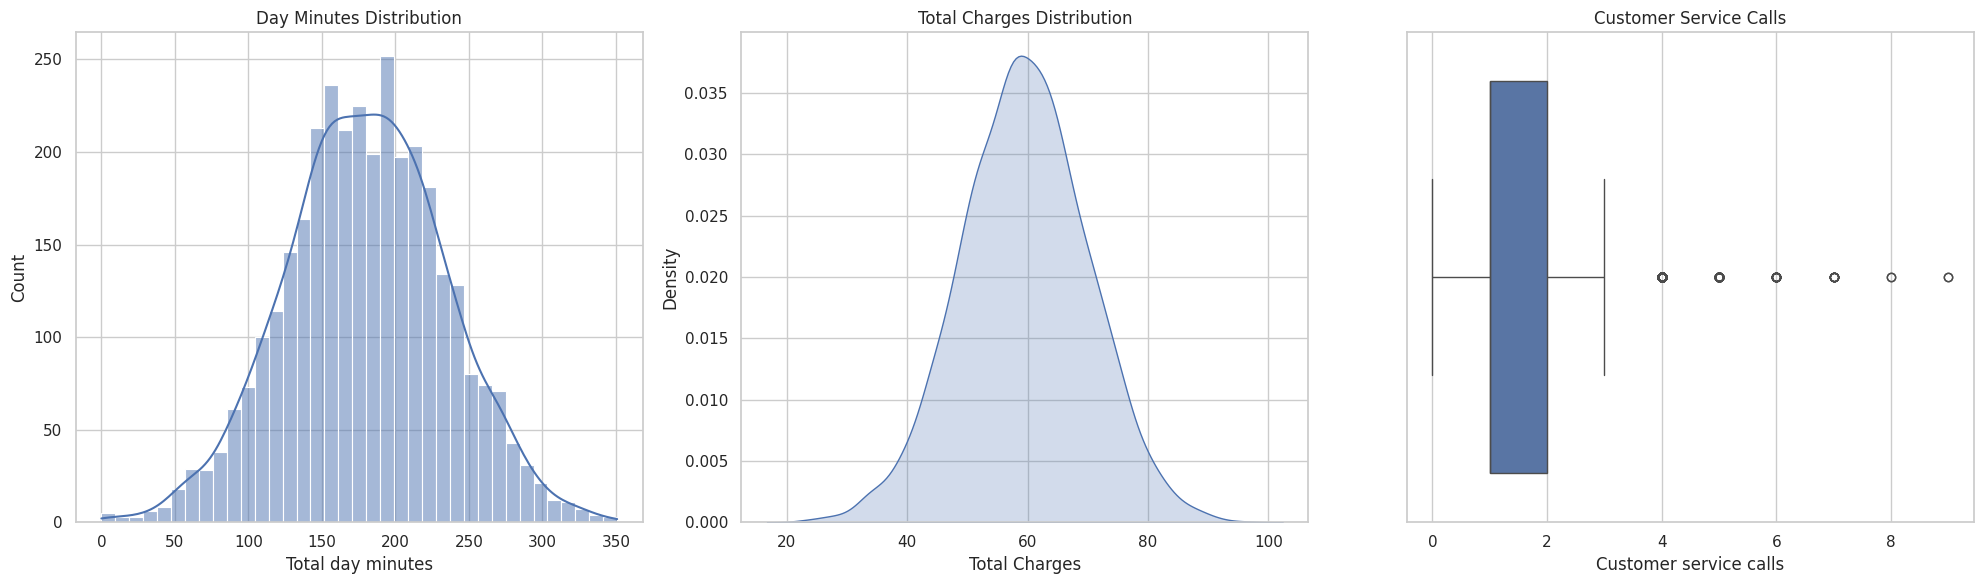

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
sns.histplot(df['Total day minutes'], kde=True, ax=ax[0])
ax[0].set_title('Day Minutes Distribution')
sns.kdeplot(df['Total Charges'], fill=True, ax=ax[1])
ax[1].set_title('Total Charges Distribution')
sns.boxplot(x=df['Customer service calls'], ax=ax[2])
ax[2].set_title('Customer Service Calls')
plt.tight_layout()
plt.show()

# Categorical

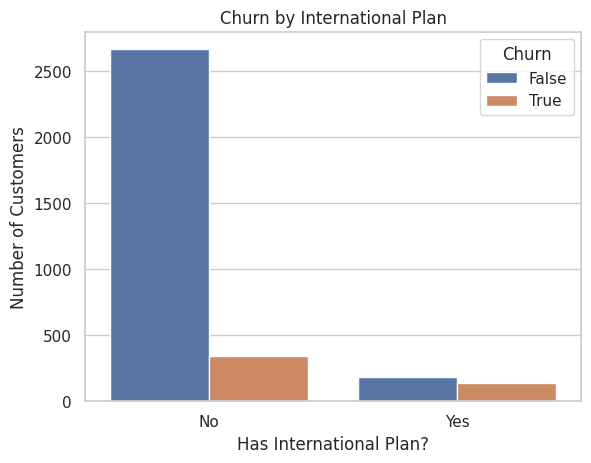

In [18]:
sns.countplot(x='International plan', hue='Churn', data=df)
plt.title('Churn by International Plan')
plt.xlabel('Has International Plan?')
plt.ylabel('Number of Customers')
plt.show()

In [19]:
#  Skewness
print(df.select_dtypes(include='number').skew().sort_values(ascending=False))

Total intl calls          1.321478
Number vmail messages     1.264824
Area code                 1.126823
Customer service calls    1.091359
Account length            0.096606
Total night calls         0.032500
Total night minutes       0.008921
Total night charge        0.008886
Total eve charge         -0.023858
Total eve minutes        -0.023877
Total day minutes        -0.029077
Total day charge         -0.029083
Total Charges            -0.034791
Total eve calls          -0.055563
Total day calls          -0.111787
Total intl minutes       -0.245136
Total intl charge        -0.245287
dtype: float64


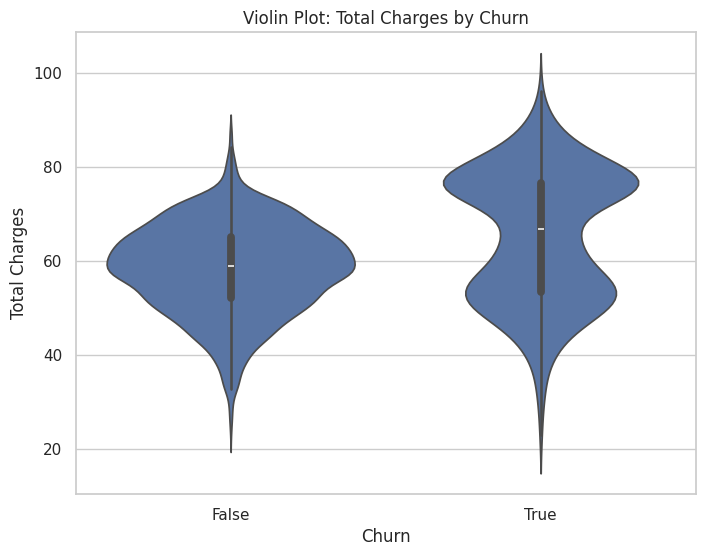

In [21]:
# Standard Bivariate
fig, axes = plt.subplots(figsize=(8, 6))
sns.violinplot(x='Churn', y='Total Charges', data=df, ax=axes)
axes.set_title("Violin Plot: Total Charges by Churn")
plt.show()

In [22]:
df['Churn'] = df['Churn'].astype(int)
correlation_with_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False).head(5)
print(correlation_with_churn)

Churn                     1.000000
Total Charges             0.231549
Customer service calls    0.208750
Total day minutes         0.205151
Total day charge          0.205151
Name: Churn, dtype: float64


In [24]:
state_churn = df.groupby('State')['Churn'].mean().sort_values(ascending=False)
print("Top 10 States with Highest Churn Rate:")
display(state_churn.head(10).round(4) * 100)

Top 10 States with Highest Churn Rate:


,Churn
State,
CA,26.47
NJ,26.47
TX,25.00
MD,24.29
SC,23.33
MI,21.92
MS,21.54
WA,21.21
NV,21.21


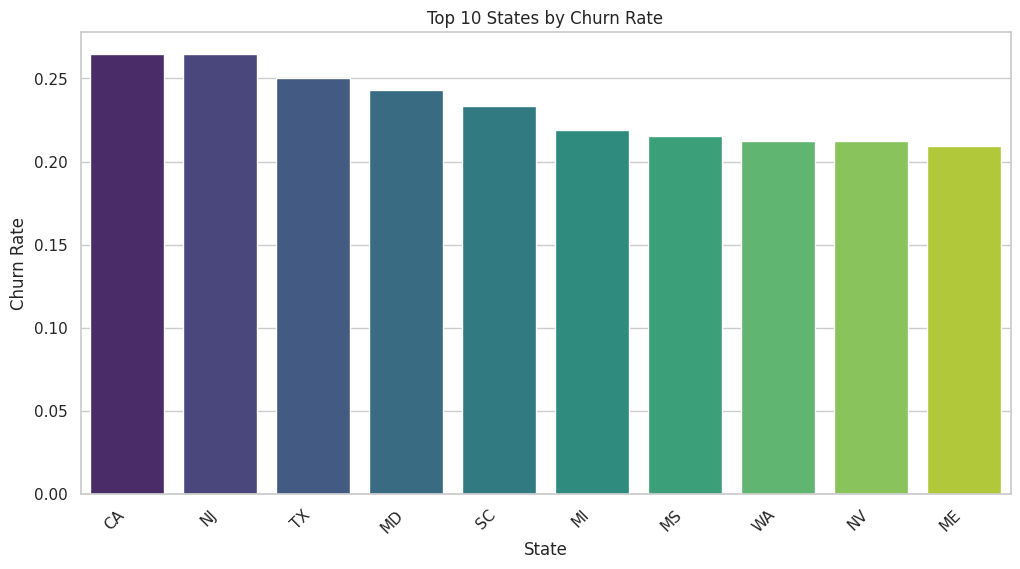

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(x=state_churn.head(10).index, y=state_churn.head(10).values, palette='viridis')
plt.title('Top 10 States by Churn Rate')
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

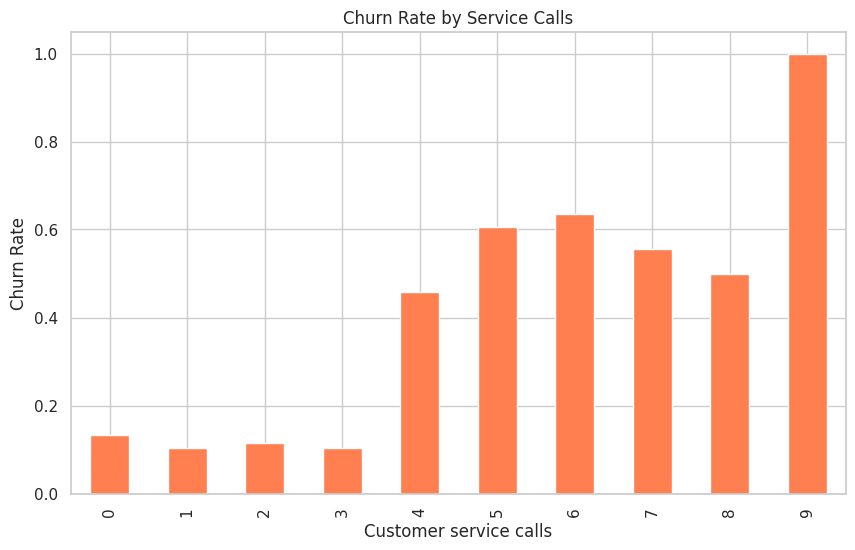

In [26]:
churn_by_calls = (df.groupby("Customer service calls")["Churn"].mean())
fig, ax = plt.subplots(figsize=(10, 6))
churn_by_calls.plot(kind="bar", color='coral', ax=ax)
ax.set_title("Churn Rate by Service Calls")
ax.set_ylabel("Churn Rate")
plt.show()

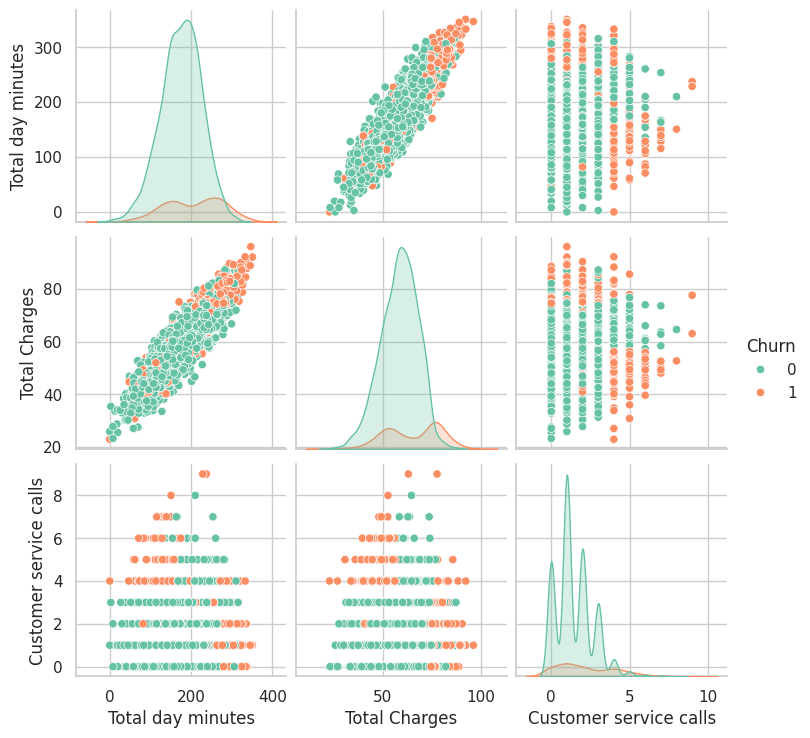

In [27]:
# Pairplot
sns.pairplot(
    df[["Total day minutes", "Total Charges", "Customer service calls", "Churn"]],
    hue="Churn",
    palette="Set2"
)
plt.show()

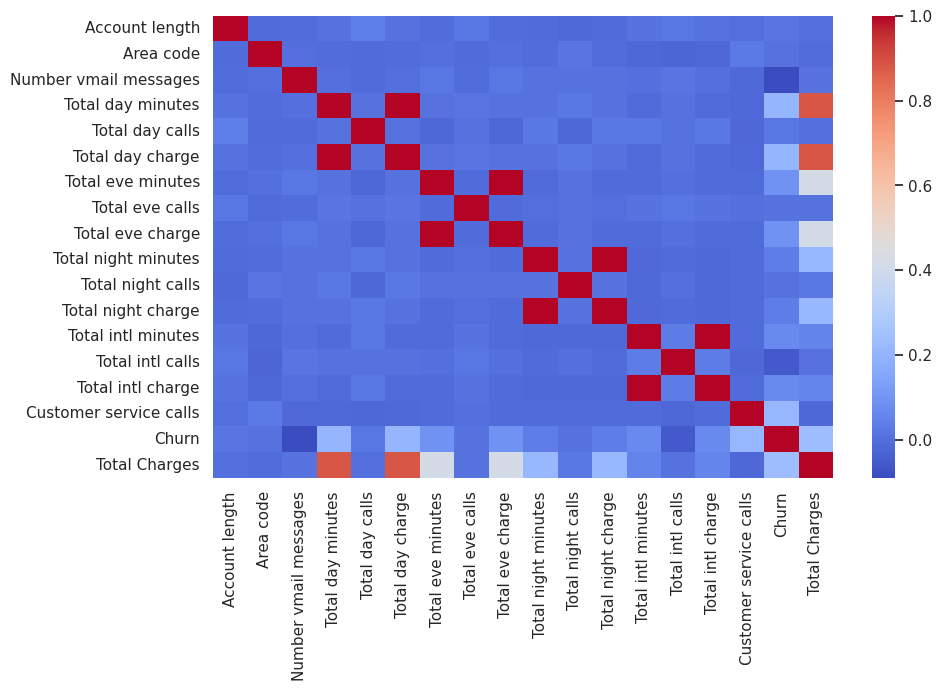

Churn,0,1
International plan,,
No,0.89,0.11
Yes,0.58,0.42


In [28]:
# Correlation Heatmap & Crosstab
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.show()
display(pd.crosstab(df['International plan'], df['Churn'], normalize='index').round(2))

Applying IQR:
  - Column 'Account length': No outliers found or already within bounds.
  - Column 'Area code': No outliers found or already within bounds.
  - Column 'Number vmail messages': No outliers found or already within bounds.
  - Column 'Total day minutes': No outliers found or already within bounds.
  - Column 'Total day calls': No outliers found or already within bounds.
  - Column 'Total day charge': No outliers found or already within bounds.
  - Column 'Total eve minutes': No outliers found or already within bounds.
  - Column 'Total eve calls': No outliers found or already within bounds.
  - Column 'Total eve charge': No outliers found or already within bounds.
  - Column 'Total night minutes': No outliers found or already within bounds.
  - Column 'Total night calls': No outliers found or already within bounds.
  - Column 'Total night charge': No outliers found or already within bounds.
  - Column 'Total intl minutes': No outliers found or already within bounds.
  - Col

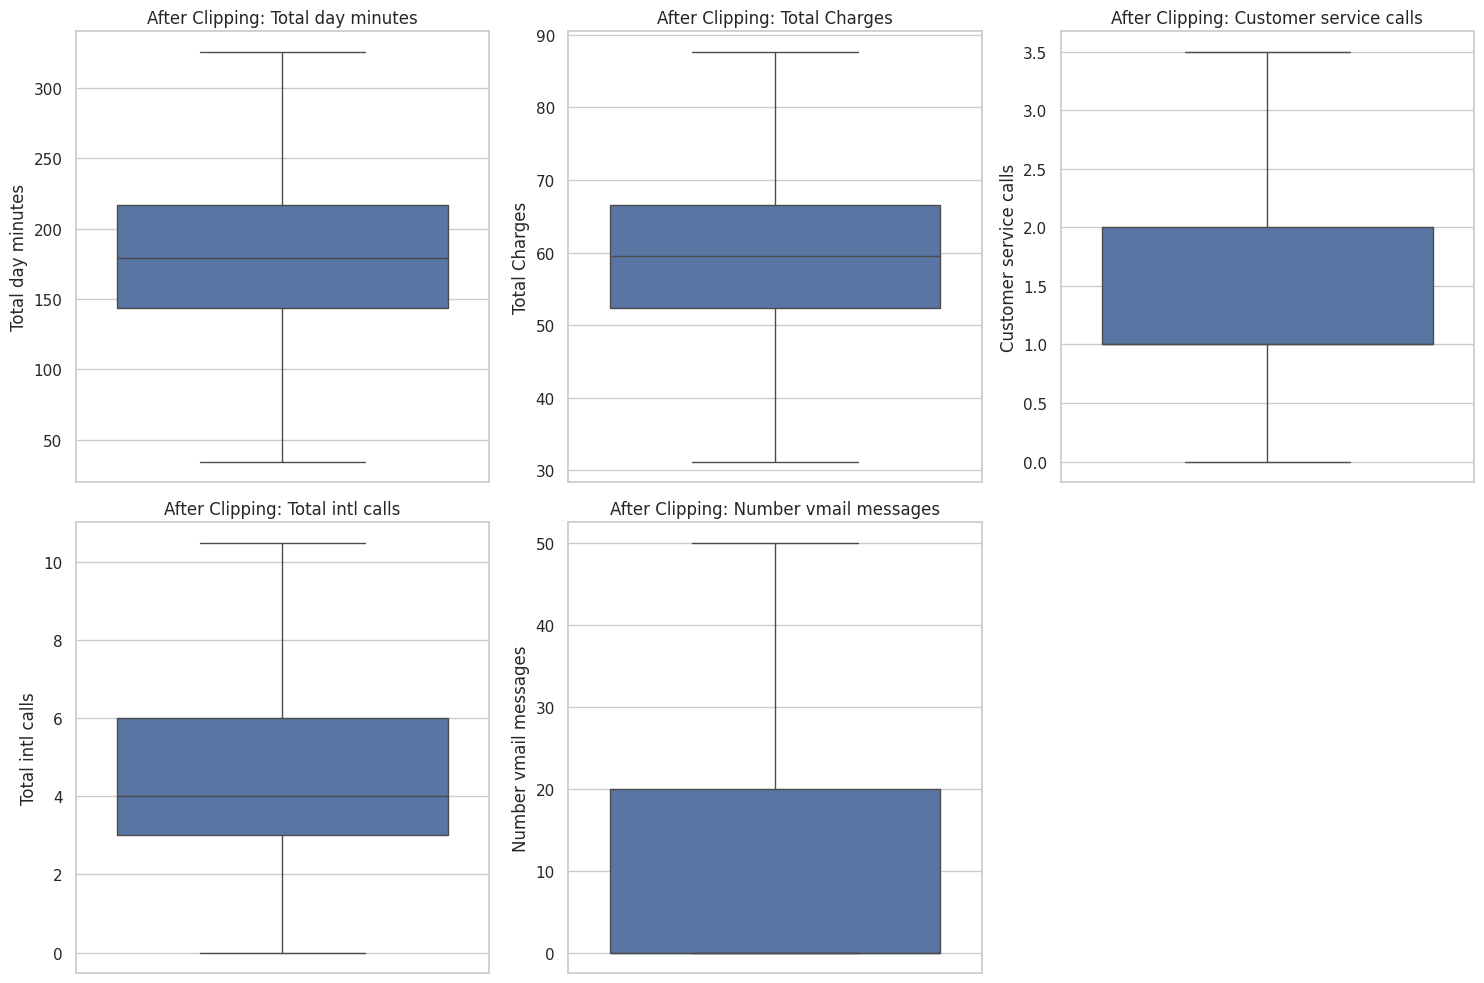

In [31]:
numeric_cols = df.select_dtypes(include=np.number).columns
print("Applying IQR:")
for col in numeric_cols:
    if col == 'Churn':
        continue
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    initial_min = df[col].min()
    initial_max = df[col].max()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    final_min = df[col].min()
    final_max = df[col].max()

    if initial_min != final_min or initial_max != final_max:
        print(f"  - Column '{col}': Outliers clipped. Min changed from {initial_min:.2f} to {final_min:.2f}, Max changed from {initial_max:.2f} to {final_max:.2f}")
    else:
        print(f"  - Column '{col}': No outliers found or already within bounds.")
cols_to_check = ['Total day minutes', 'Total Charges', 'Customer service calls',
                 'Total intl calls', 'Number vmail messages']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_to_check, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'After Clipping: {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# **Section 7: Feature Engineering**

In [32]:
df['Total_Usage'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes']
df['Service_Stress'] = df['Customer service calls'] / (df['Account length'] + 1)
df['Revenue_Segment'] = pd.qcut(df['Total Charges'], q=3, labels=['Low', 'Medium', 'High'])

In [37]:
display(df[['Total_Usage', 'Service_Stress', 'Revenue_Segment']].head(10))

,Total_Usage,Service_Stress,Revenue_Segment
0,717.20,0.007752,High
1,625.20,0.009259,Medium
2,539.40,0.000000,Medium
3,566.45,0.023529,High
4,512.00,0.039474,Low
5,654.20,0.000000,High
6,776.65,0.024590,High
7,479.00,0.000000,Low
8,818.20,0.000000,High
9,556.20,0.000000,Medium


# **Section 8: Feature Encoding**

In [33]:
le = LabelEncoder()
df['International plan'] = le.fit_transform(df['International plan'])
df['Voice mail plan'] = le.fit_transform(df['Voice mail plan'])
df['Churn'] = le.fit_transform(df['Churn'])
df = pd.get_dummies(df, columns=['State', 'Revenue_Segment'], drop_first=True, dtype=int)

# **Section 9: Feature Selection**

In [38]:
corr_matrix = df.corr(numeric_only=True).abs()
high_corr = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr.add(corr_matrix.columns[i])

print(f"Dropping highly correlated data-driven columns: {high_corr}")
df.drop(columns=high_corr, inplace=True)

Dropping highly correlated data-driven columns: {'Number vmail messages', 'Total night charge', 'Total eve charge', 'Total intl charge', 'Total day charge'}


# **Section 10: Feature Scaling**

In [39]:
# Drop Area Code
df.drop('Area code', axis=1, inplace=True, errors='ignore')
print("Note: 'Area code' was dropped because it acts as an arbitrary ID and has no predictive power for churn.")

Note: 'Area code' was dropped because it acts as an arbitrary ID and has no predictive power for churn.


# **Section 11: Train-Test Split & Scaling Comparison**

In [40]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Compare Scalers
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()